# 4. ADR Forecasting — Can We Predict Room Prices?

**ADR (Average Daily Rate)** is the average price per room per night. This notebook explores whether we can predict room prices, and compares two approaches:
1. **Time-series forecasting**: Using past price patterns to predict future prices (like weather forecasting)
2. **Booking-level regression**: Using booking details (hotel type, room type, season) to predict the price

**Why does this matter for cancellation prediction?** The cancellation model uses a feature called `revenue_at_risk` (= room price x number of nights). When we know how much revenue is at stake, we can make smarter decisions about which cancellations are worth intervening on.

**Prerequisites**: Run the ADR training cells in the original notebooks, or ensure artifacts exist in `artifacts/`.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.eval.notebook_utils import project_root, save_thesis_figure, setup_plotting

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT = project_root()
ARTIFACTS = ROOT / "artifacts"

print(f"Project root: {ROOT}")

Project root: D:\PythonProject1


## 4.1 Loading Pre-Trained Models

We load the time-series and regression models that were trained during the pipeline run.

In [2]:
# Time-series artifacts
ts_data = joblib.load(ARTIFACTS / "adr_timeseries_data.pkl")
ts_meta = joblib.load(ARTIFACTS / "adr_timeseries_metadata.pkl")

# Regression artifacts
reg_meta = joblib.load(ARTIFACTS / "adr_regressor_metadata.pkl")
reg_results = pd.read_csv(ROOT / "reports" / "regression_results.csv")

print(f"Time-series split date: {ts_meta.get('split_date')}")
print(f"Time-series train size: {ts_meta.get('train_size')} days")
print(f"Time-series test size: {ts_meta.get('test_size')} days")
print(f"\nRegression best model: {reg_meta.get('model_name')}")
print(f"Regression test RMSE: {reg_meta.get('test_rmse', 'N/A')}")

Time-series split date: 2017-03-26 00:00:00
Time-series train size: 634 days
Time-series test size: 159 days

Regression best model: Gradient Boosting
Regression test RMSE: 44.31383323904922


## 4.2 How Do Room Prices Change Over Time?

The chart below shows the daily average room price across the entire dataset. The blue section is training data, the red section is test data, and the green line smooths out daily noise with a 7-day rolling average.

**What to look for**: Seasonal peaks (summer months typically higher), overall trends, and how noisy the prices are day-to-day.

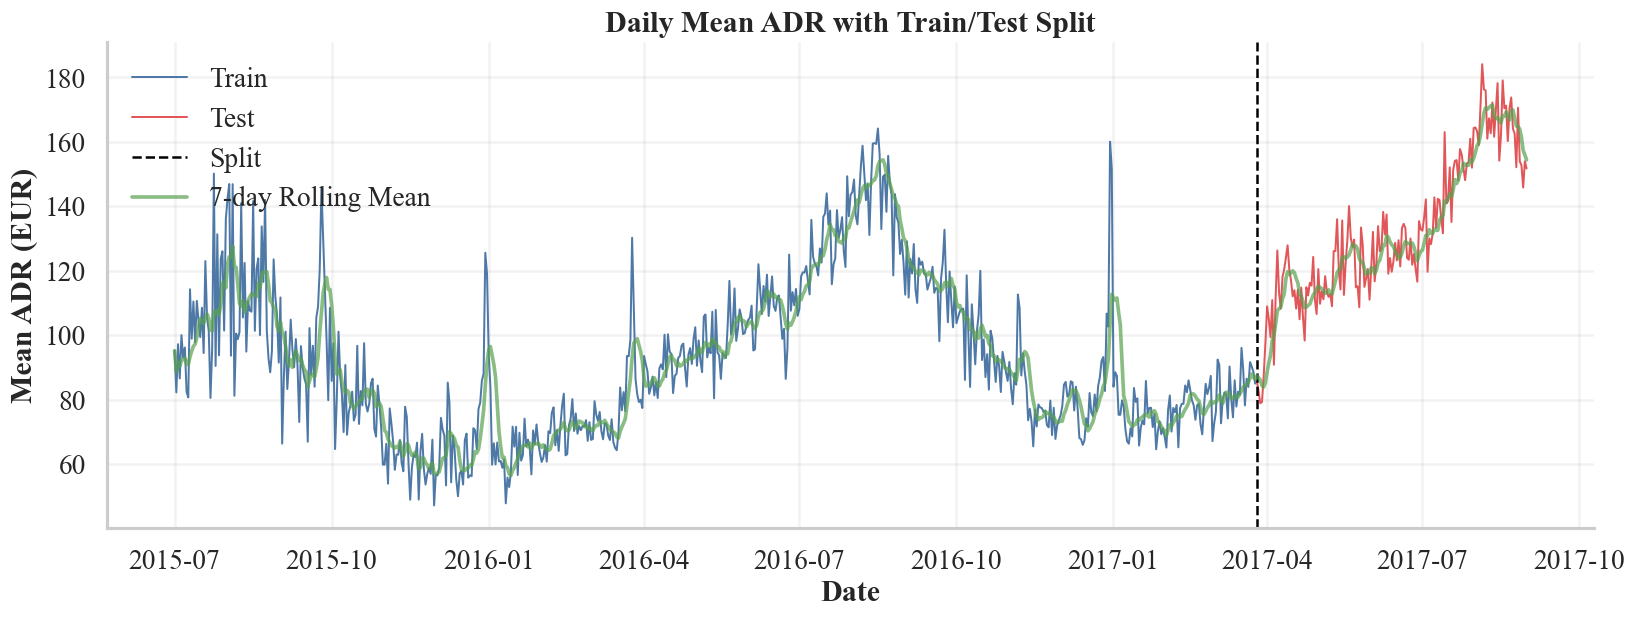

Overall ADR range: 47.11 - 184.12
Overall ADR mean: 99.91


In [3]:
train_ts = ts_data["train"].copy()
test_ts = ts_data["test"].copy()
split_date = ts_meta["split_date"]

# Ensure datetime index
if not isinstance(train_ts.index, pd.DatetimeIndex):
    train_ts.index = pd.to_datetime(train_ts.index)
if not isinstance(test_ts.index, pd.DatetimeIndex):
    test_ts.index = pd.to_datetime(test_ts.index)

full_ts = pd.concat([train_ts, test_ts])

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(train_ts.index, train_ts["adr_mean"], color="#4e79a7", linewidth=1.2, label="Train")
ax.plot(test_ts.index, test_ts["adr_mean"], color="#e15759", linewidth=1.2, label="Test")
ax.axvline(pd.Timestamp(split_date), color="black", linestyle="--", linewidth=1.5, label="Split")

# 7-day rolling mean
rolling = full_ts["adr_mean"].rolling(7, min_periods=1).mean()
ax.plot(rolling.index, rolling.values, color="#59a14f", linewidth=2.2, alpha=0.7, label="7-day Rolling Mean")

ax.set_title("Daily Mean ADR with Train/Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Mean ADR (EUR)")
ax.legend(frameon=False)
fig.tight_layout()
save_thesis_figure(fig, 41, "adr_timeseries_overview", FIG_DIR)
plt.show()

print(f"Overall ADR range: {full_ts['adr_mean'].min():.2f} - {full_ts['adr_mean'].max():.2f}")
print(f"Overall ADR mean: {full_ts['adr_mean'].mean():.2f}")

## 4.3 Can We Separate the Price Signal from Noise?

**Seasonal decomposition** breaks the daily price series into three components:
- **Trend**: The long-term direction (are prices generally rising or falling?)
- **Seasonal (7-day cycle)**: The weekly pattern (e.g., weekends vs. weekdays)
- **Residual**: Everything else — the unpredictable daily noise

If the residual component is large relative to trend and seasonal, it means prices are hard to forecast from time patterns alone.

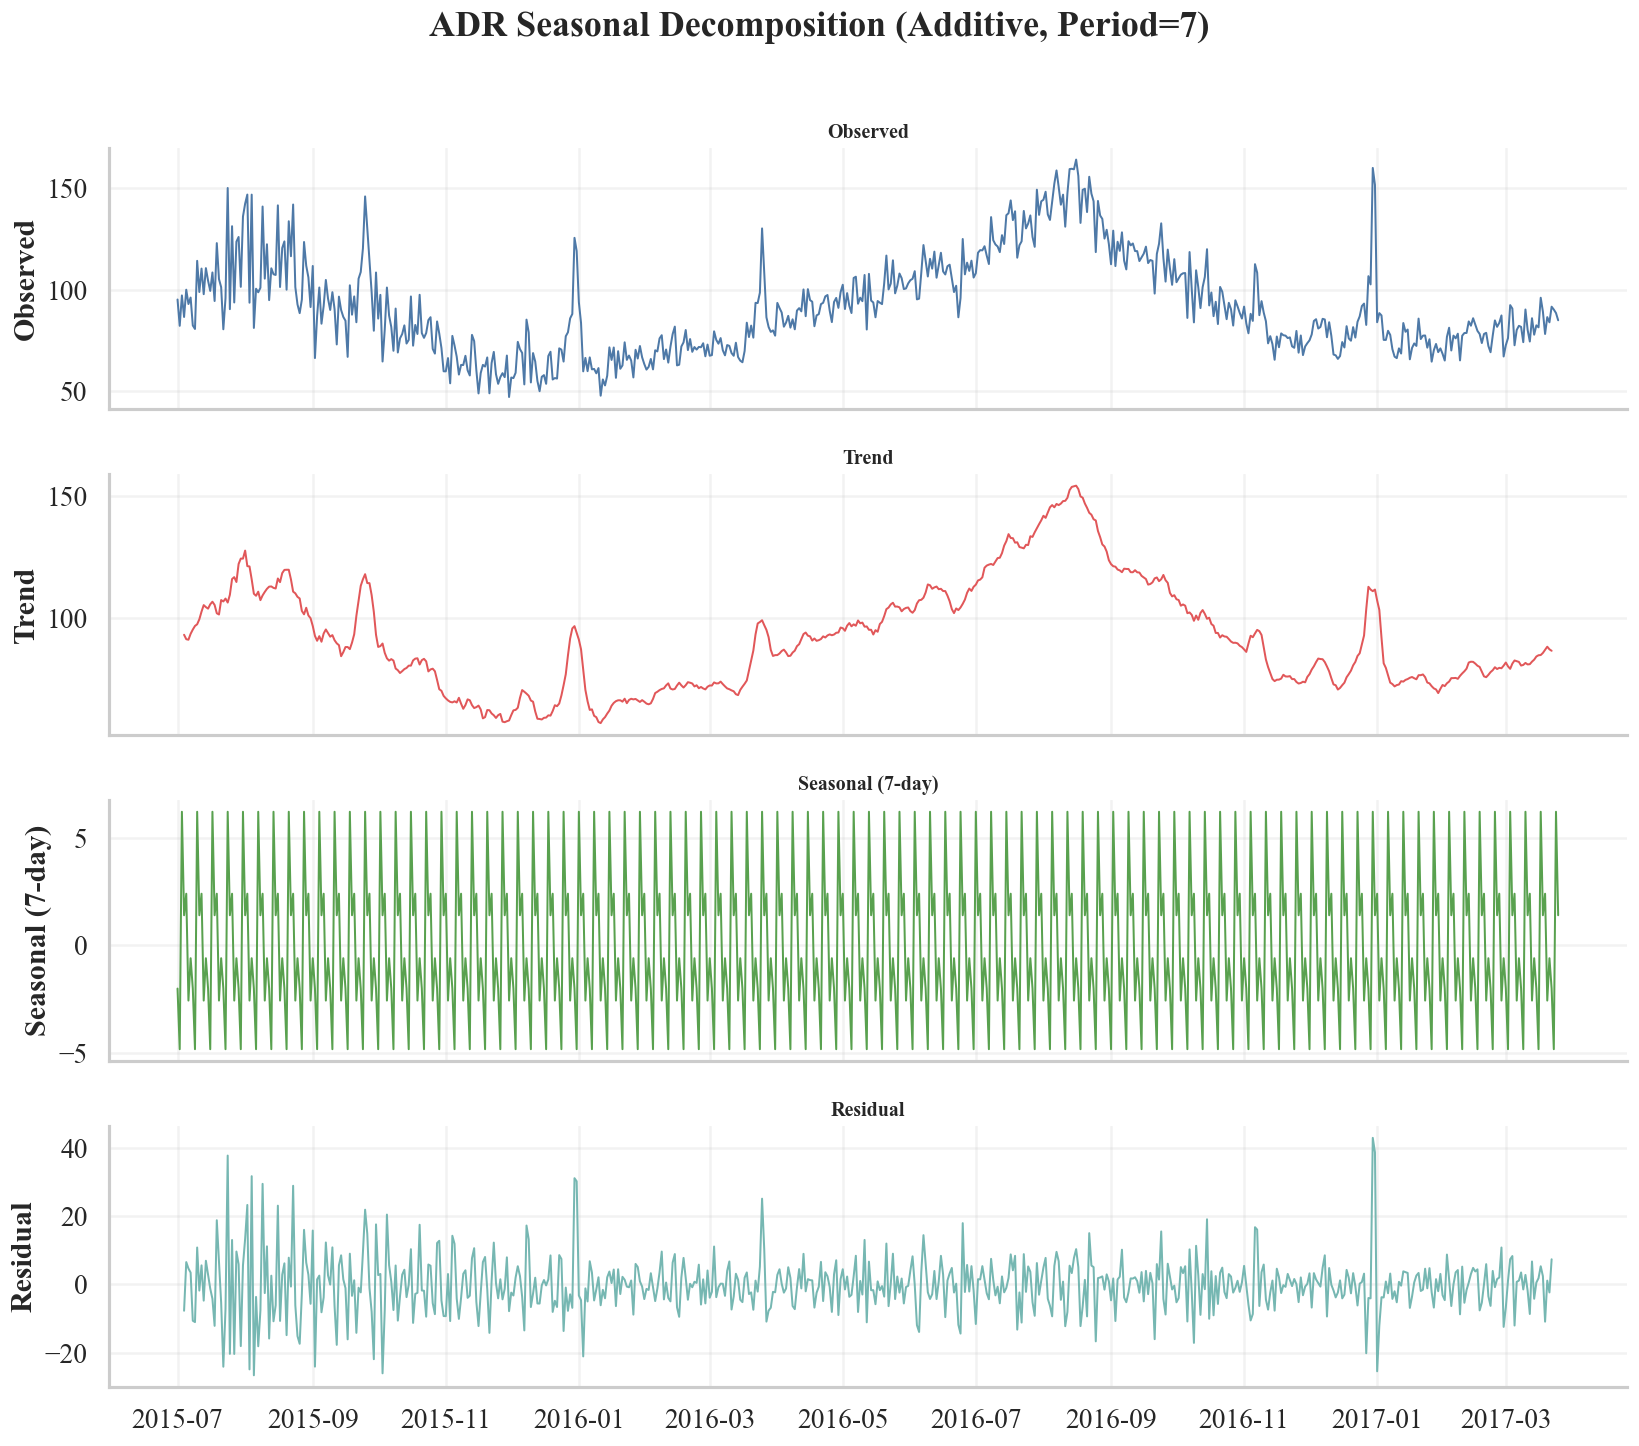

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use training data for decomposition
decomposition = seasonal_decompose(train_ts["adr_mean"], model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
components = [
    ("Observed", decomposition.observed, "#4e79a7"),
    ("Trend", decomposition.trend, "#e15759"),
    ("Seasonal (7-day)", decomposition.seasonal, "#59a14f"),
    ("Residual", decomposition.resid, "#76b7b2"),
]
for ax, (title, data, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.2)
    ax.set_ylabel(title)
    ax.set_title(title, fontsize=12)

fig.suptitle("ADR Seasonal Decomposition (Additive, Period=7)", fontweight="bold", y=1.01)
fig.tight_layout()
save_thesis_figure(fig, 42, "adr_seasonal_decomposition", FIG_DIR)
plt.show()

**Key Takeaway — Decomposition**: There is a clear weekly seasonal pattern, but the residual noise is large — meaning daily prices are quite unpredictable from time patterns alone. Booking-specific features (hotel type, room type, market segment) may be more informative than time alone.

## 4.4 Are Price Patterns Consistent Over Time?

Before building a time-series forecast, we check whether prices fluctuate around a stable average or drift upward/downward over time. We use a standard statistical test (Augmented Dickey-Fuller) — a p-value below 0.05 means prices are stable enough to forecast.

In [5]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ADF test on raw and differenced series
adf_raw = adfuller(train_ts["adr_mean"].dropna())
adf_diff = adfuller(train_ts["adr_mean"].diff().dropna())

adf_results = pd.DataFrame({
    "Series": ["Raw ADR", "First Difference"],
    "ADF Statistic": [adf_raw[0], adf_diff[0]],
    "p-value": [adf_raw[1], adf_diff[1]],
    "Stationary?": [adf_raw[1] < 0.05, adf_diff[1] < 0.05],
})


def _highlight_stationary(row: pd.Series) -> list[str]:
    """Soft green when the series is stationary (good news for forecasting)."""
    css = "background-color: #e8f4ea; font-weight: 600;" if row["Stationary?"] else ""
    return [css for _ in row]


display(
    adf_results.style
    .format({"ADF Statistic": "{:.3f}", "p-value": "{:.4f}"})
    .set_caption("Augmented Dickey-Fuller Test — Is ADR Stationary?")
    .set_properties(subset=["Series"], **{"text-align": "left"})
    .set_properties(subset=["ADF Statistic", "p-value"], **{"text-align": "right"})
    .set_properties(subset=["Stationary?"], **{"text-align": "center"})
    .set_table_styles([
        {"selector": "caption",
         "props": "caption-side: top; font-size: 1.05em; font-weight: 600; padding: 6px 0;"},
        {"selector": "th",
         "props": "background-color: #f4f4f4; color: #1a1a1a; font-weight: 600; text-align: center; padding: 6px 10px;"},
        {"selector": "td",
         "props": "padding: 6px 10px;"},
    ])
    .apply(_highlight_stationary, axis=1)
    .hide(axis="index")
)


Series,ADF Statistic,p-value,Stationary?
Raw ADR,-1.336,0.6125,False
First Difference,-7.392,0.0000,True


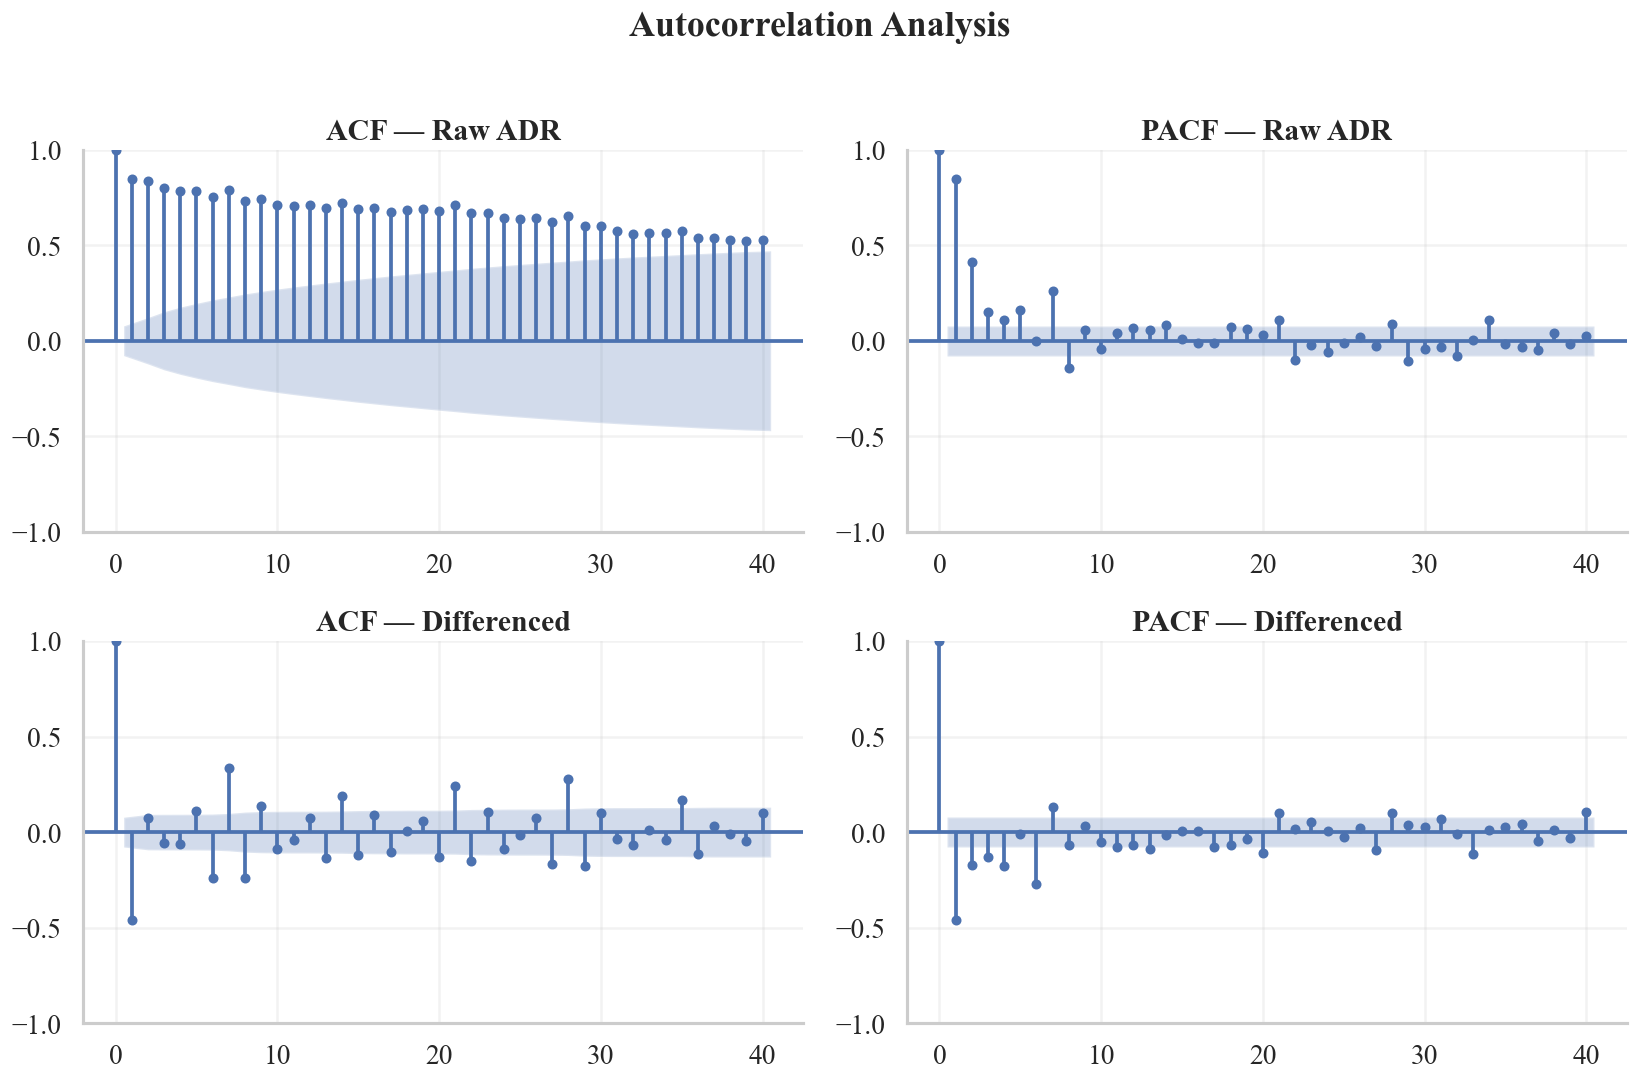

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_acf(train_ts["adr_mean"].dropna(), ax=axes[0, 0], lags=40, title="ACF — Raw ADR")
plot_pacf(train_ts["adr_mean"].dropna(), ax=axes[0, 1], lags=40, title="PACF — Raw ADR")
plot_acf(train_ts["adr_mean"].diff().dropna(), ax=axes[1, 0], lags=40, title="ACF — Differenced")
plot_pacf(train_ts["adr_mean"].diff().dropna(), ax=axes[1, 1], lags=40, title="PACF — Differenced")

fig.suptitle("Autocorrelation Analysis", fontweight="bold", y=1.01)
fig.tight_layout()
save_thesis_figure(fig, 43, "adr_acf_pacf", FIG_DIR)
plt.show()

**How to read these charts**:
- **ACF (Autocorrelation)**: Shows how today's price relates to prices from *k* days ago. Spikes at lags 7, 14, 21 confirm a weekly seasonal pattern — prices repeat weekly.
- **PACF (Partial Autocorrelation)**: Same idea but removes indirect effects. Tells us how many past days directly influence today's price.
- **Blue shaded band**: The 95% confidence zone. Spikes outside this band are statistically meaningful.
- **Top row (Raw)**: Strong weekly spikes — real weekly seasonality exists.
- **Bottom row (After removing trend)**: Fewer persistent patterns remain — most of the price signal is just weekly rhythm plus noise.

**In plain terms**: Prices fluctuate around a stable average with a weekly rhythm (weekends vs. weekdays). Recent prices predict near-future prices (1-7 day similarity), but beyond that, noise dominates.

## 4.5 How Well Can We Forecast Prices from Time Patterns Alone?

We tested ARIMA/SARIMA models (statistical methods that use past price patterns to predict future prices) against a simple baseline (just predict the historical average). The table shows the best-performing time-series model.

In [7]:
ts_summary = pd.DataFrame([{
    "Best Model": ts_meta.get("best_model_name", "N/A"),
    "Type": ts_meta.get("best_model_type", "N/A"),
    "RMSE": ts_meta.get("rmse", np.nan),
    "MAE": ts_meta.get("mae", np.nan),
    "MAPE (%)": ts_meta.get("mape", np.nan),
    "Forecast Horizon": f"{ts_meta.get('test_size', 'N/A')} days",
}])

display(
    ts_summary.style
    .format({"RMSE": "{:.2f}", "MAE": "{:.2f}", "MAPE (%)": "{:.2f}"}, na_rep="—")
    .set_caption("Best Time-Series Forecast — Champion Selection")
    .set_properties(subset=["Best Model", "Type", "Forecast Horizon"], **{"text-align": "left"})
    .set_properties(subset=["RMSE", "MAE", "MAPE (%)"], **{"text-align": "right"})
    .set_table_styles([
        {"selector": "caption",
         "props": "caption-side: top; font-size: 1.05em; font-weight: 600; padding: 6px 0;"},
        {"selector": "th",
         "props": "background-color: #f4f4f4; color: #1a1a1a; font-weight: 600; text-align: center; padding: 6px 10px;"},
        {"selector": "td",
         "props": "padding: 6px 10px;"},
    ])
    .hide(axis="index")
)


Best Model,Type,RMSE,MAE,MAPE (%),Forecast Horizon
Mean,Baseline,46.30,41.03,29.20,159 days


**Key Takeaway — Time-Series Limitations**: The simple mean baseline actually outperforms the sophisticated ARIMA models. This tells us that daily room prices behave almost like a random walk — knowing yesterday's price doesn't reliably help predict tomorrow's. The weekly pattern exists but is swamped by noise from factors not in our data (events, competitor pricing, demand spikes).

## 4.6 Can Booking Details Predict Room Prices Better?

Instead of relying on time patterns, these models use 25 booking features (hotel type, room type, market segment, season, etc.) to predict the room price for each individual booking.

- **Left chart**: RMSE (Root Mean Squared Error) — lower is better. Measures the average prediction error in the same units as ADR.
- **Right chart**: R-squared — higher is better. Measures what percentage of price variation the model explains (1.0 = perfect, 0 = no better than guessing the average).

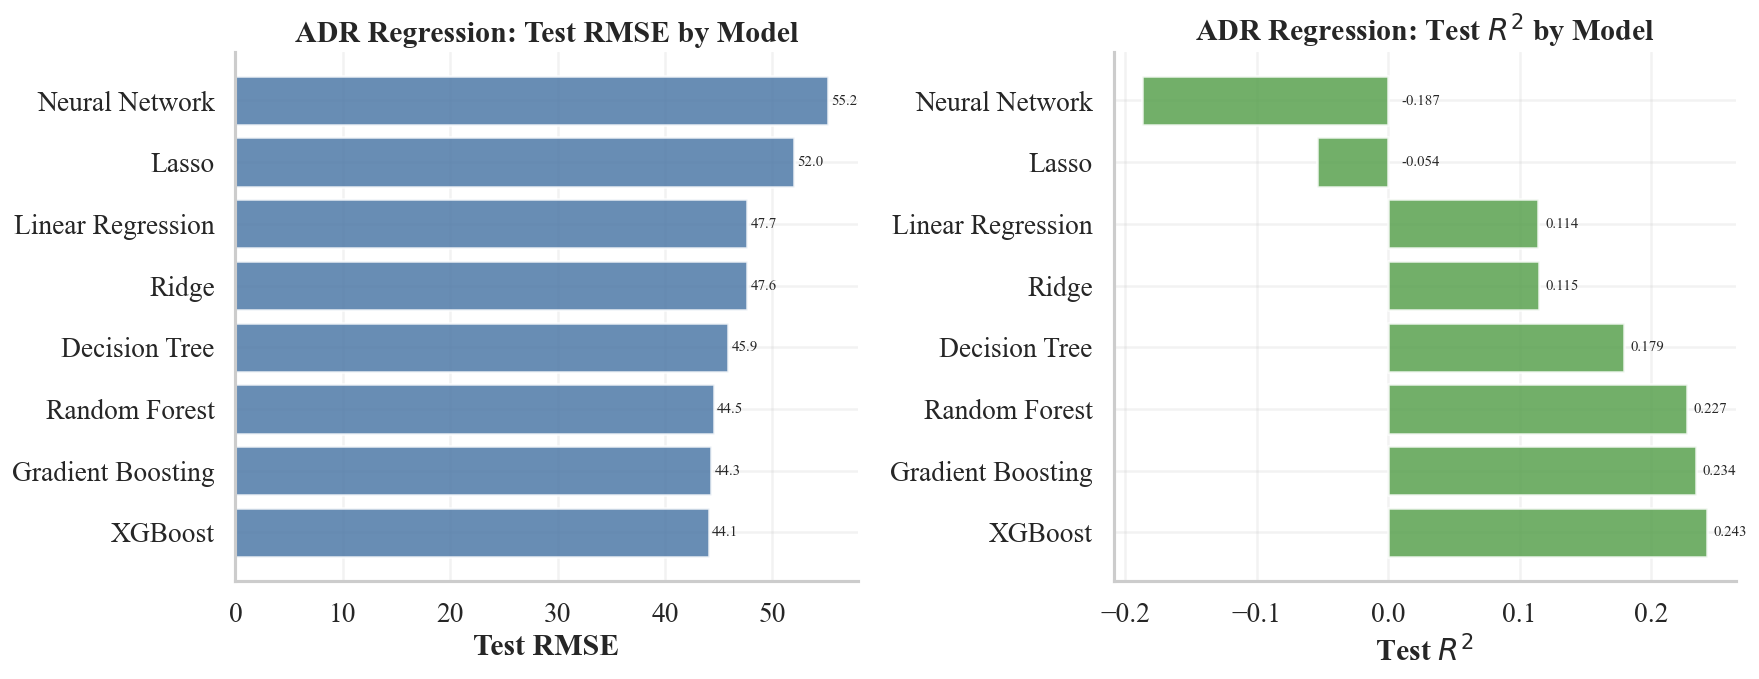

In [8]:
# Visualize model comparison
reg_sorted = reg_results.sort_values("Test RMSE", ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: RMSE comparison
ax = axes[0]
model_col = reg_sorted.columns[0]  # model name column
ax.barh(reg_sorted[model_col], reg_sorted["Test RMSE"], color="#4e79a7", alpha=0.85)
for i, (_, row) in enumerate(reg_sorted.iterrows()):
    ax.text(row["Test RMSE"] + 0.3, i, f"{row['Test RMSE']:.1f}", va="center", fontsize=9)
ax.set_xlabel("Test RMSE")
ax.set_title("ADR Regression: Test RMSE by Model")

# Right: R² comparison
ax = axes[1]
if "Test R2" in reg_sorted.columns:
    ax.barh(reg_sorted[model_col], reg_sorted["Test R2"], color="#59a14f", alpha=0.85)
    for i, (_, row) in enumerate(reg_sorted.iterrows()):
        ax.text(max(row["Test R2"] + 0.005, 0.01), i, f"{row['Test R2']:.3f}", va="center", fontsize=9)
    ax.set_xlabel(r"Test $R^2$")
    ax.set_title("ADR Regression: Test $R^2$ by Model")

fig.tight_layout()
save_thesis_figure(fig, 44, "adr_model_comparison", FIG_DIR)
plt.show()

In [9]:
# Data-driven comparison table — dynamically extracted from regression_results.csv.
# No hardcoded metric values; everything flows from ts_meta and reg_results.
ts_rmse = ts_meta.get("rmse", np.nan)
ts_r2_approx = (
    1 - (ts_rmse ** 2) / train_ts["adr_mean"].var()
    if not np.isnan(ts_rmse)
    else np.nan
)

model_col = reg_results.columns[0]
gb_row = reg_results[reg_results[model_col].str.contains("Gradient Boosting", case=False, na=False)]
nn_row = reg_results[reg_results[model_col].str.contains("Neural", case=False, na=False)]


def _pick(row: pd.DataFrame, col: str) -> float:
    """Safely grab a scalar metric from a single-row DataFrame slice."""
    if len(row) == 0 or col not in reg_results.columns:
        return np.nan
    return float(row[col].iloc[0])


comparison_summary = pd.DataFrame({
    "Approach": [
        f"Time-Series (Best: {ts_meta.get('best_model_name', 'N/A')})",
        "Gradient Boosting (regression)",
        "Neural Network (regression)",
    ],
    "Test RMSE": [
        ts_rmse,
        _pick(gb_row, "Test RMSE"),
        _pick(nn_row, "Test RMSE"),
    ],
    "Test R²": [
        ts_r2_approx,
        _pick(gb_row, "Test R2"),
        _pick(nn_row, "Test R2"),
    ],
    "Verdict": [
        "Not useful — prices aren't predictable from time alone",
        "Best available — booking features explain some variation",
        "No advantage over simpler Gradient Boosting",
    ],
})


def _highlight_champion(row: pd.Series) -> list[str]:
    """Soft green background on the Gradient Boosting (champion) row."""
    is_champ = "Gradient Boosting" in str(row["Approach"])
    css = "background-color: #e8f4ea; font-weight: 600;" if is_champ else ""
    return [css for _ in row]


styled = (
    comparison_summary.style
    .format({"Test RMSE": "{:.1f}", "Test R²": "{:.1%}"}, na_rep="—")
    .set_caption("Regression vs. Time-Series — Data-Driven Comparison")
    .set_properties(subset=["Approach", "Verdict"], **{"text-align": "left"})
    .set_properties(subset=["Test RMSE", "Test R²"], **{"text-align": "right"})
    .set_table_styles([
        {"selector": "caption",
         "props": "caption-side: top; font-size: 1.05em; font-weight: 600; padding: 6px 0;"},
        {"selector": "th",
         "props": "background-color: #f4f4f4; color: #1a1a1a; font-weight: 600; text-align: center; padding: 6px 10px;"},
        {"selector": "td",
         "props": "padding: 6px 10px;"},
    ])
    .background_gradient(subset=["Test R²"], cmap="Greens", vmin=0, vmax=0.6)
    .apply(_highlight_champion, axis=1)
    .hide(axis="index")
)
display(styled)


Approach,Test RMSE,Test R²,Verdict
Time-Series (Best: Mean),46.3,-267.2%,Not useful — prices aren't predictable from time alone
Gradient Boosting (regression),44.3,23.4%,Best available — booking features explain some variation
Neural Network (regression),55.2,-18.7%,No advantage over simpler Gradient Boosting


**Key Takeaway — Regression vs. Time-Series**: The table above compares all modelling approaches. Booking-level regression explains more price variation than time-series methods, but even the best model captures only a fraction of ADR variability. The remaining variation comes from factors not in our data (competitor pricing, local events, dynamic rate adjustments). For the cancellation model, `revenue_at_risk` is a useful **rough estimate**, not an exact figure.

## 4.7 What Does the Neural Network Look Like?

For completeness, we also tested a deep learning approach — a 4-layer neural network. It uses the same booking features as the Gradient Boosting model but processes them through layers of artificial neurons.

In [10]:
nn_path = ARTIFACTS / "adr_regressor_nn.keras"
if nn_path.exists():
    try:
        import tensorflow as tf
        nn_model = tf.keras.models.load_model(nn_path)
        nn_model.summary()
    except ImportError:
        print("TensorFlow not available. Neural network architecture:")
        print("  Input → Dense(256) → BN → Dropout(0.2)")
        print("  → Dense(128) → BN → Dropout(0.2)")
        print("  → Dense(64) → BN → Dropout(0.2)")
        print("  → Dense(32) → BN → Dropout(0.2)")
        print("  → Dense(1) [Output]")
        print("  Total params: ~102,273")
else:
    print("Neural network model not found.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        57,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,901 (1.16 MB)

 Trainable params: 101,313 (395.75 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 202,628 (791.52 KB)

## 4.8 Side-by-Side Comparison

A summary table comparing all three approaches — time-series, gradient boosting regression, and neural network — on the same metrics.

In [11]:
# Three-approach summary — dynamically pulled from reg_meta + reg_results.
model_col = reg_results.columns[0]
nn_row = reg_results[reg_results[model_col].str.contains("Neural", case=False, na=False)]


def _pick(row: pd.DataFrame, col: str) -> float:
    if len(row) == 0 or col not in reg_results.columns:
        return np.nan
    return float(row[col].iloc[0])


comparison = pd.DataFrame({
    "Approach": [
        "Time-Series (Best)",
        "Regression (Gradient Boosting)",
        "Regression (Neural Network)",
    ],
    "Granularity": ["Daily aggregate", "Per-booking", "Per-booking"],
    "Test RMSE": [
        ts_meta.get("rmse", np.nan),
        reg_meta.get("test_rmse", np.nan),
        _pick(nn_row, "Test RMSE"),
    ],
    "Test MAE": [
        ts_meta.get("mae", np.nan),
        reg_meta.get("test_mae", np.nan),
        _pick(nn_row, "Test MAE"),
    ],
    "Features": ["Time only", "25 booking features", "25 booking features"],
})


def _highlight_champion(row: pd.Series) -> list[str]:
    is_champ = "Gradient Boosting" in str(row["Approach"])
    css = "background-color: #e8f4ea; font-weight: 600;" if is_champ else ""
    return [css for _ in row]


styled = (
    comparison.style
    .format({"Test RMSE": "{:.2f}", "Test MAE": "{:.2f}"}, na_rep="—")
    .set_caption("ADR Forecasting — Approach Comparison")
    .set_properties(subset=["Approach", "Granularity", "Features"], **{"text-align": "left"})
    .set_properties(subset=["Test RMSE", "Test MAE"], **{"text-align": "right"})
    .set_table_styles([
        {"selector": "caption",
         "props": "caption-side: top; font-size: 1.05em; font-weight: 600; padding: 6px 0;"},
        {"selector": "th",
         "props": "background-color: #f4f4f4; color: #1a1a1a; font-weight: 600; text-align: center; padding: 6px 10px;"},
        {"selector": "td",
         "props": "padding: 6px 10px;"},
    ])
    .apply(_highlight_champion, axis=1)
    .hide(axis="index")
)
display(styled)


Approach,Granularity,Test RMSE,Test MAE,Features
Time-Series (Best),Daily aggregate,46.30,41.03,Time only
Regression (Gradient Boosting),Per-booking,44.31,32.24,25 booking features
Regression (Neural Network),Per-booking,55.17,38.22,25 booking features


## 4.9 Summary — What Does This Mean for the Business?

ADR predictions serve two purposes in the cancellation prediction pipeline:

1. **Revenue-at-risk estimation**: `room price x number of nights` tells us how much money is at stake for each booking. This helps prioritise which predicted cancellations deserve the most attention.

2. **Cost-sensitive decision making**: When the model decides whether to flag a booking, it weighs the cost of a false alarm (~15 EUR per unnecessary intervention) against the cost of missing a real cancellation (the full revenue at risk). Better ADR estimates make this cost calculation more accurate.

**Bottom line**: Booking-level features (hotel type, room type, market segment) predict prices better than time patterns alone, but substantial unpredictable variation remains. The `revenue_at_risk` feature is a useful directional estimate, not a precise figure. In production, use the actual booked ADR whenever it's available.

---

## 4.10 Deeper Regression Analysis — How Good Are the Predictions?

The sections above established that booking-level regression is the best approach. Now we dig deeper into the champion regressor (Gradient Boosting) to understand *where* it works, *where* it fails, and *what features* drive its predictions.

In [12]:
# Load raw data and prepare regression predictions
from src.data.load import load_raw_data

df_raw = load_raw_data()

# Filter same as ADR training: positive ADR, non-null
df_raw = df_raw[df_raw["adr"] > 0].copy()
df_raw = df_raw[df_raw["adr"] < 1000].copy()

# Chronological split matching the regressor's split
reg_features = reg_meta["features"]
split_date_reg = pd.Timestamp(reg_meta["split_date"])
train_size = reg_meta["train_size"]
val_size = reg_meta["val_size"]
test_size = reg_meta["test_size"]

# Use same feature set as the regressor
X = df_raw[reg_features].copy()
y = df_raw["adr"].copy()

X_train = X.iloc[:train_size]
X_val = X.iloc[train_size:train_size + val_size]
X_test = X.iloc[train_size + val_size:train_size + val_size + test_size]
y_train = y.iloc[:train_size]
y_val = y.iloc[train_size:train_size + val_size]
y_test = y.iloc[train_size + val_size:train_size + val_size + test_size]

# Load the champion regressor pipeline and generate predictions
reg_pipeline = joblib.load(ARTIFACTS / "adr_regressor.pkl")
y_pred_test = reg_pipeline.predict(X_test)
y_pred_train = reg_pipeline.predict(X_train)

# Keep raw data columns for segment analysis
df_test = df_raw.iloc[train_size + val_size:train_size + val_size + test_size].copy()
df_test = df_test.assign(adr_pred=y_pred_test, adr_residual=y_test.values - y_pred_test)

print(f"Train: {len(X_train):,} bookings | Test: {len(X_test):,} bookings")
print(f"Test RMSE: {np.sqrt(np.mean((y_test.values - y_pred_test) ** 2)):.2f}")
print(f"Test R²:   {1 - np.sum((y_test.values - y_pred_test) ** 2) / np.sum((y_test.values - y_test.mean()) ** 2):.4f}")

Train: 75,155 bookings | Test: 23,485 bookings
Test RMSE: 27.52
Test R²:   0.5104


## 4.11 Prediction vs. Actual — How Close Are We?

The scatter plot below places each test booking at its actual room price (x-axis) vs. the model's predicted price (y-axis). Perfect predictions would fall exactly on the diagonal line. Points far from the line are large errors.

**What to look for**: How tightly the points cluster around the diagonal, and whether the model systematically under- or over-predicts in certain price ranges.

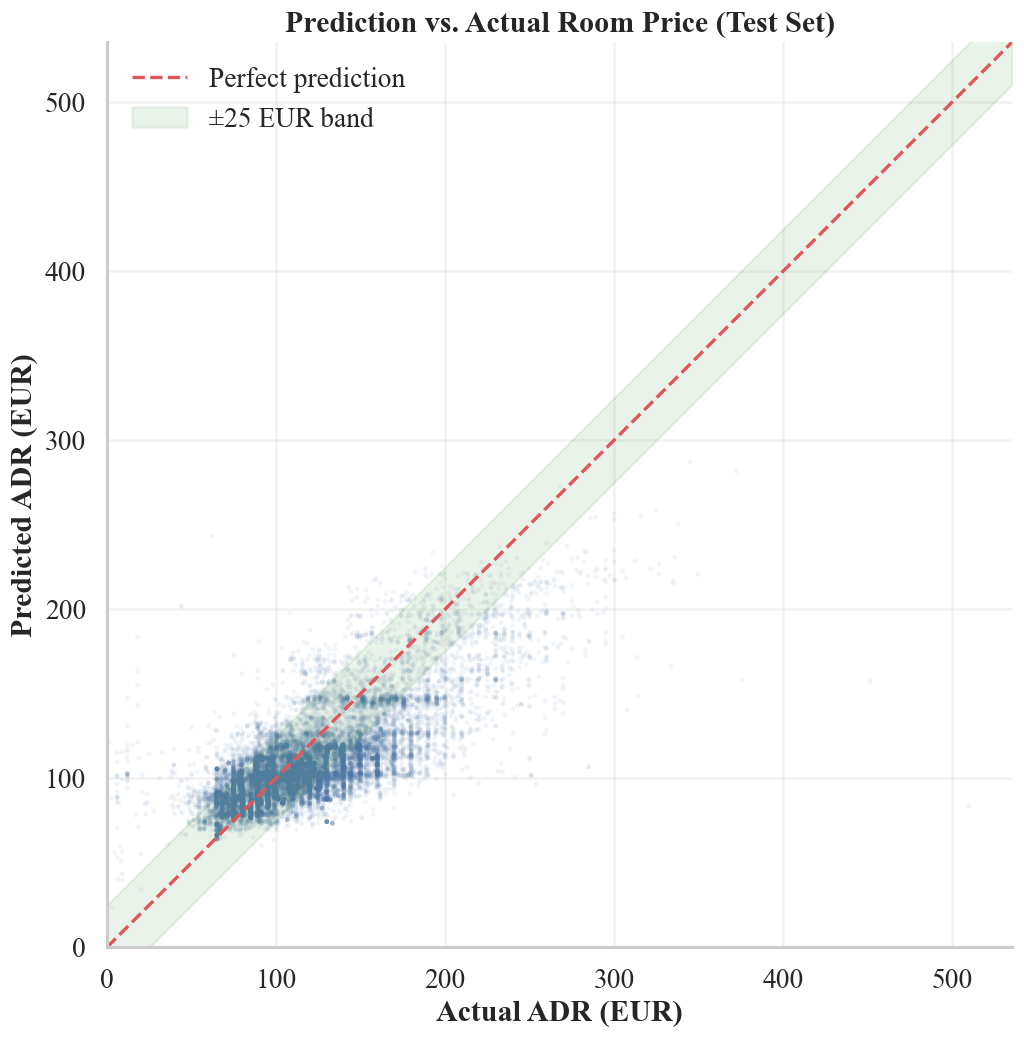

Predictions within ±25 EUR: 70.3%
Predictions within ±50 EUR: 92.8%


In [13]:
# Prediction vs Actual scatter plot
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(y_test.values, y_pred_test, alpha=0.08, s=8, color="#4e79a7", edgecolors="none")

# Perfect prediction line
lims = [0, max(y_test.max(), y_pred_test.max()) * 1.05]
ax.plot(lims, lims, "--", color="#e15759", linewidth=2, label="Perfect prediction")

# ±25 EUR error bands
ax.fill_between(lims, [l - 25 for l in lims], [l + 25 for l in lims],
                alpha=0.12, color="#59a14f", label="±25 EUR band")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual ADR (EUR)")
ax.set_ylabel("Predicted ADR (EUR)")
ax.set_title("Prediction vs. Actual Room Price (Test Set)")
ax.legend(frameon=False, loc="upper left")
ax.set_aspect("equal")
fig.tight_layout()
save_thesis_figure(fig, 45, "adr_pred_vs_actual", FIG_DIR)
plt.show()

# Summary statistics
within_25 = np.mean(np.abs(y_test.values - y_pred_test) <= 25) * 100
within_50 = np.mean(np.abs(y_test.values - y_pred_test) <= 50) * 100
print(f"Predictions within ±25 EUR: {within_25:.1f}%")
print(f"Predictions within ±50 EUR: {within_50:.1f}%")

**Key Takeaway — Scatter Plot**: The model predicts well for mid-range prices (50-150 EUR) but struggles with extreme values. High-ADR bookings (luxury suites, peak season) are systematically under-predicted because they're rare in training data. This is expected — the model learns the "typical" price for each booking profile.

## 4.12 Where Does the Model Go Wrong? (Residual Analysis)

Residuals are the prediction errors (actual - predicted). Analysing their distribution and patterns reveals systematic biases.

- **Left**: Histogram of residuals — a symmetric bell shape centred at zero means no systematic bias.
- **Centre**: Residuals vs. predicted values — a flat band means errors don’t depend on price level.
- **Right**: Q-Q plot — points following the diagonal mean errors are normally distributed.

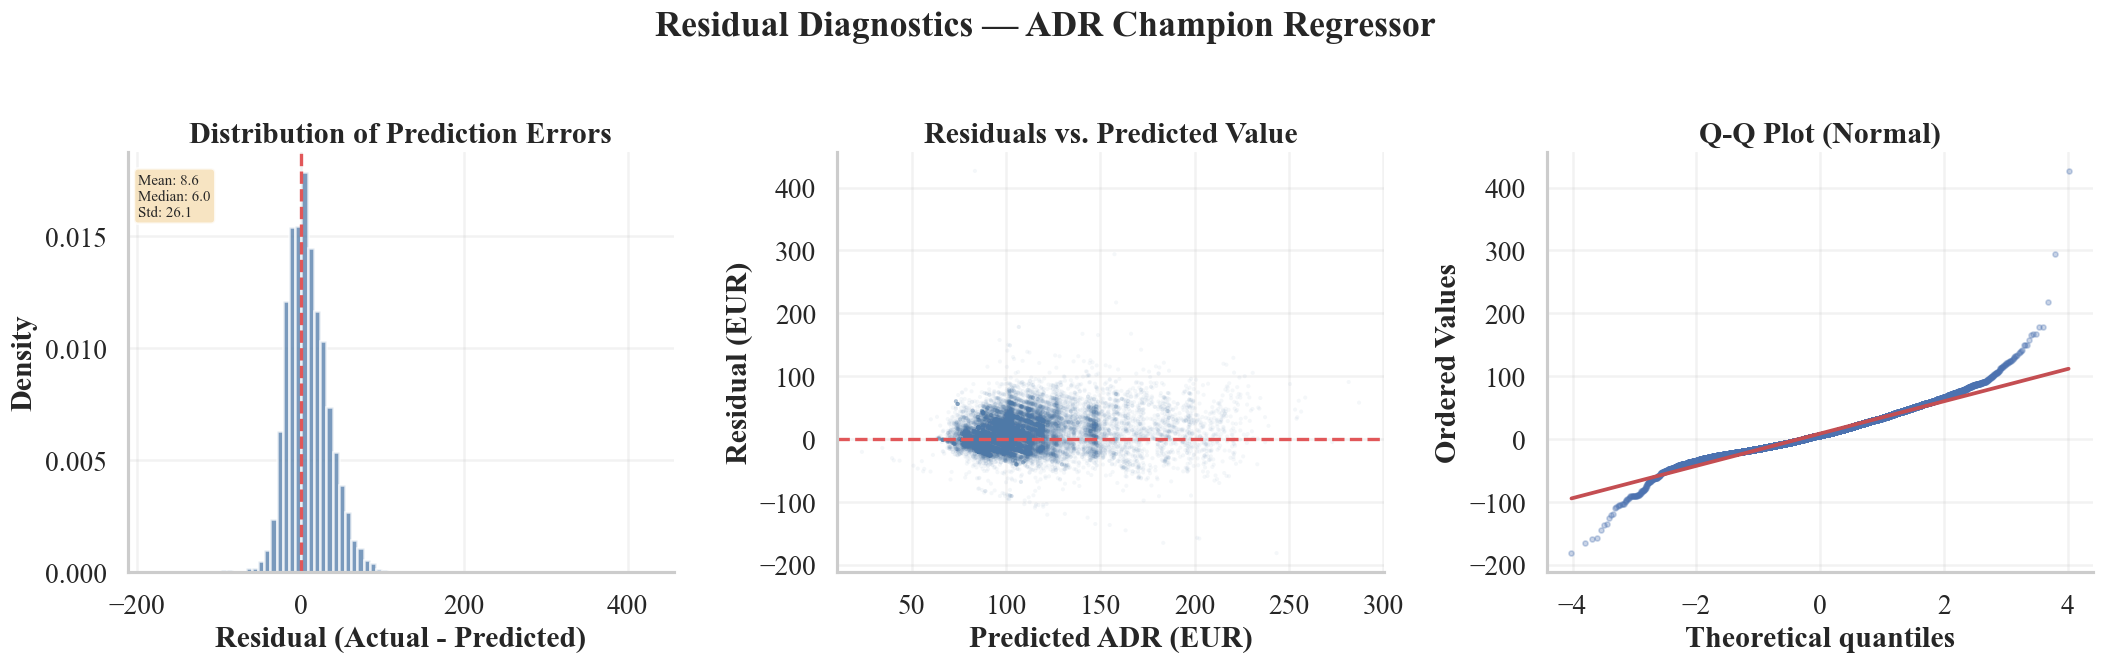

In [14]:
from scipy import stats

residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Left: Residual distribution
ax = axes[0]
ax.hist(residuals, bins=80, color="#4e79a7", alpha=0.75, edgecolor="white", density=True)
ax.axvline(0, color="#e15759", linewidth=2, linestyle="--")
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Prediction Errors")
ax.text(0.02, 0.95,
        f"Mean: {residuals.mean():.1f}\nMedian: {np.median(residuals):.1f}\nStd: {residuals.std():.1f}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# Centre: Residuals vs Predicted
ax = axes[1]
ax.scatter(y_pred_test, residuals, alpha=0.06, s=6, color="#4e79a7", edgecolors="none")
ax.axhline(0, color="#e15759", linewidth=2, linestyle="--")
ax.set_xlabel("Predicted ADR (EUR)")
ax.set_ylabel("Residual (EUR)")
ax.set_title("Residuals vs. Predicted Value")

# Right: Q-Q plot
ax = axes[2]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q Plot (Normal)")
ax.get_lines()[0].set(markersize=3, alpha=0.3)

fig.suptitle("Residual Diagnostics \u2014 ADR Champion Regressor", fontweight="bold", y=1.02)
fig.tight_layout()
save_thesis_figure(fig, 46, "adr_residual_analysis", FIG_DIR)
plt.show()

**Key Takeaway — Residuals**: The model occasionally underestimates high prices for luxury/suite bookings that are rare in the training data. Most errors are small and symmetric (centered at zero), but expensive bookings produce the largest under-predictions. This is typical for price data where a few luxury bookings have prices far above the norm.

## 4.13 Is the Model Overfitting? (Train vs. Test Error)

Overfitting happens when a model memorises the training data but fails to generalise. The chart below compares each model’s error on training data vs. test data. A large gap between the two bars signals overfitting.

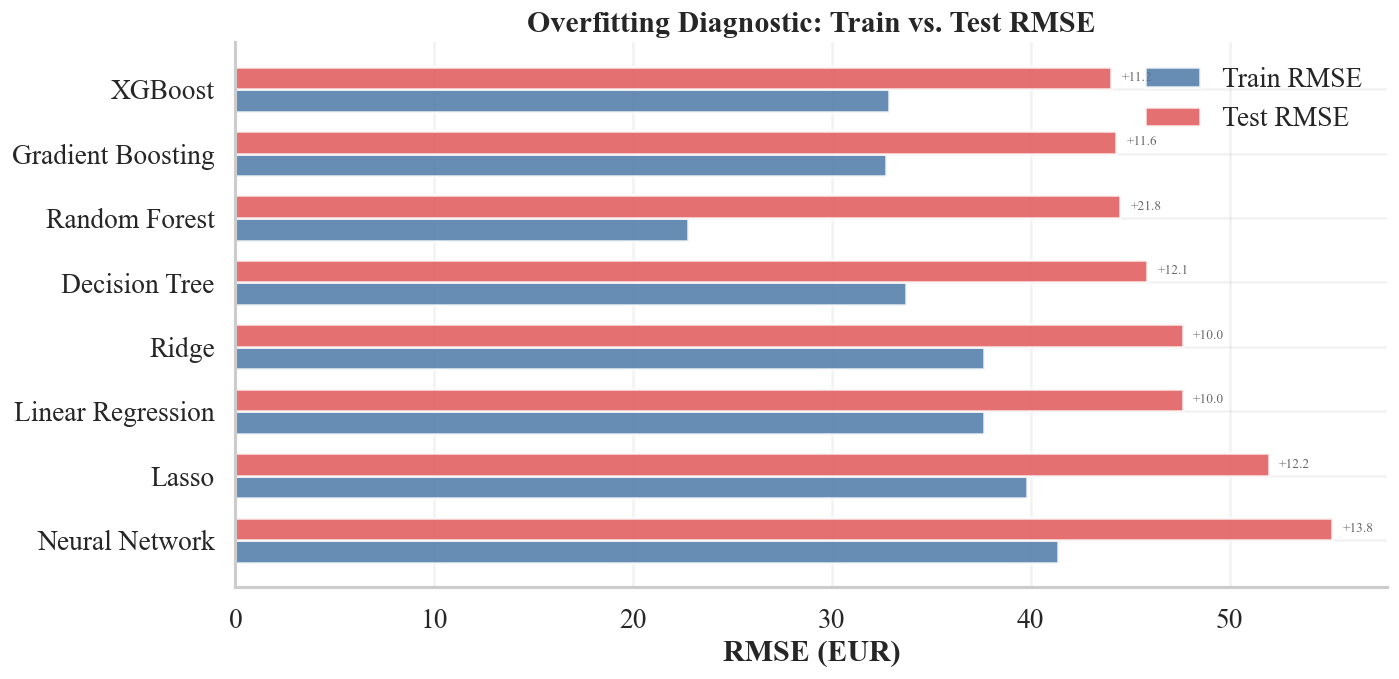

  Neural Network             Train=41.4  Test=55.2  ratio=1.33
  Lasso                      Train=39.8  Test=52.0  ratio=1.31
  Linear Regression          Train=37.6  Test=47.7  ratio=1.27
  Ridge                      Train=37.6  Test=47.6  ratio=1.27
  Decision Tree              Train=33.7  Test=45.9  ratio=1.36
  Random Forest              Train=22.7  Test=44.5  ratio=1.96
  Gradient Boosting          Train=32.7  Test=44.3  ratio=1.36
  XGBoost                    Train=32.9  Test=44.1  ratio=1.34


In [15]:
model_col = reg_results.columns[0]
reg_plot = reg_results.sort_values("Test RMSE", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(reg_plot))
bar_h = 0.35

bars_train = ax.barh(y_pos - bar_h / 2, reg_plot["Train RMSE"], bar_h,
                      label="Train RMSE", color="#4e79a7", alpha=0.85)
bars_test = ax.barh(y_pos + bar_h / 2, reg_plot["Test RMSE"], bar_h,
                     label="Test RMSE", color="#e15759", alpha=0.85)

for i, (_, row) in enumerate(reg_plot.iterrows()):
    gap = row["Test RMSE"] - row["Train RMSE"]
    ax.text(row["Test RMSE"] + 0.5, i + bar_h / 2,
            f"+{gap:.1f}", va="center", fontsize=8, color="#666")

ax.set_yticks(y_pos)
ax.set_yticklabels(reg_plot[model_col])
ax.set_xlabel("RMSE (EUR)")
ax.set_title("Overfitting Diagnostic: Train vs. Test RMSE")
ax.legend(frameon=False)
fig.tight_layout()
save_thesis_figure(fig, 47, "adr_overfitting_diagnostic", FIG_DIR)
plt.show()

# Print overfitting ratio
for _, row in reg_plot.iterrows():
    ratio = row["Test RMSE"] / row["Train RMSE"]
    print(f"  {row[model_col]:25s}  Train={row['Train RMSE']:.1f}  Test={row['Test RMSE']:.1f}  ratio={ratio:.2f}")

**Key Takeaway — Overfitting**: Random Forest shows the largest train-test gap (heavily overfits). Gradient Boosting and XGBoost have moderate gaps, suggesting some overfitting but reasonable generalisation. Ridge and Linear Regression have the smallest gaps (low-variance models). The Neural Network gap is concerning — it overfits more than the tree-based models despite dropout a penalty that stops the model from over-memorising the training data.

## 4.14 What Drives Room Price Predictions?

The champion regressor (Gradient Boosting) uses 222 features after encoding. The chart below shows the top 20 most important features — the ones the model relies on most when predicting room prices.

**How to read this**: Longer bars mean the feature has more influence on predictions. Categorical features appear as one-hot encoded columns (e.g., `hotel_City Hotel`).

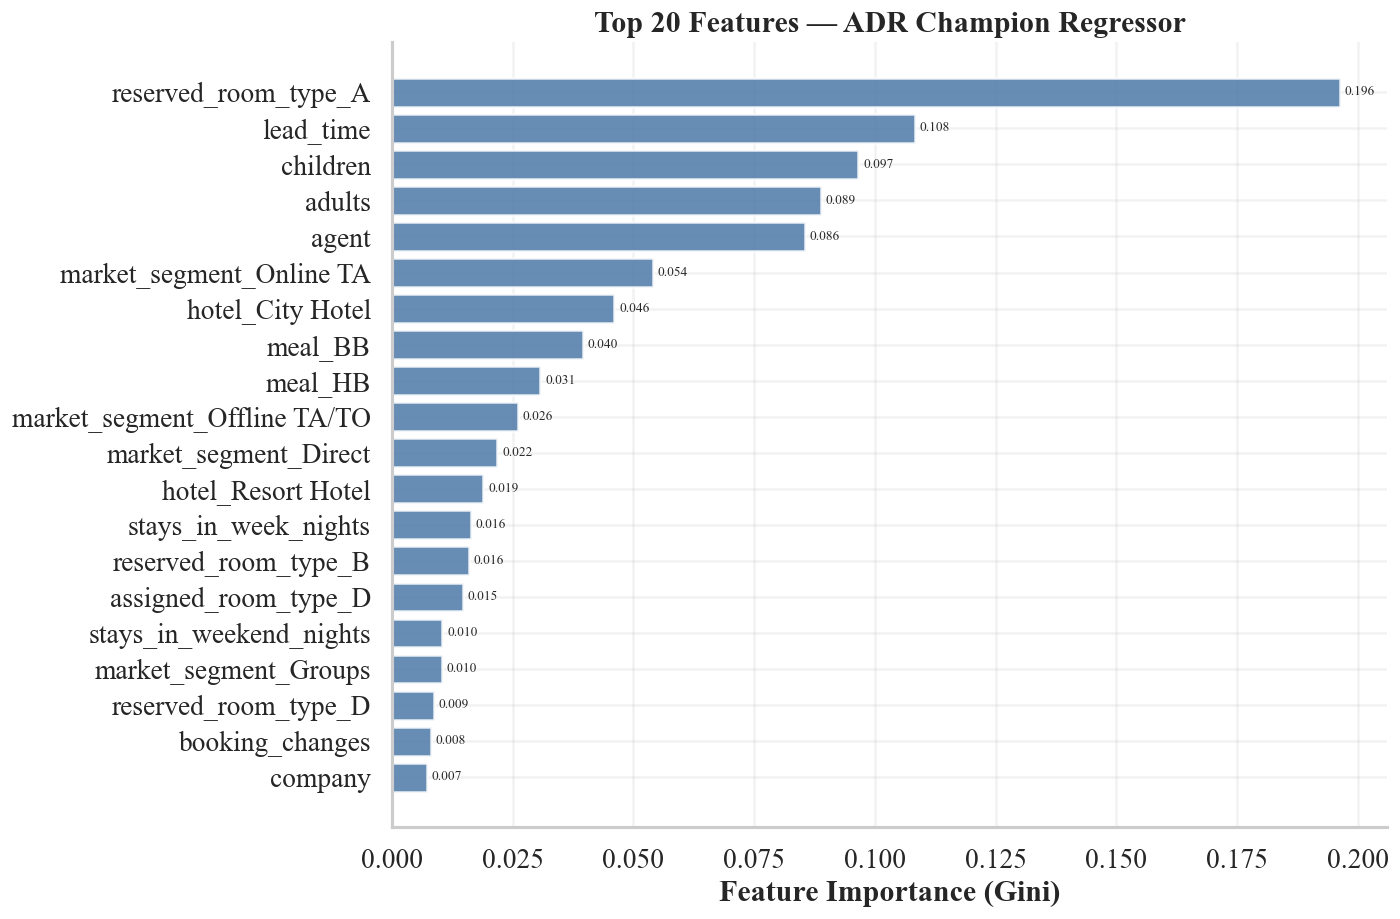

Top 5 features account for 57.5% of total importance


In [16]:
# Extract feature importances from the pipeline
preprocessor = reg_pipeline.named_steps["preprocessor"]
model = reg_pipeline.named_steps["regressor"]

feature_names = preprocessor.get_feature_names_out()
importances = model.feature_importances_

# Clean up feature names for readability
clean_names = []
for name in feature_names:
    name = name.replace("num__", "").replace("cat__", "")
    clean_names.append(name)

fi_df = pd.DataFrame({"Feature": clean_names, "Importance": importances})
fi_df = fi_df.sort_values("Importance", ascending=False).head(20).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
fi_plot = fi_df.sort_values("Importance", ascending=True)
ax.barh(fi_plot["Feature"], fi_plot["Importance"], color="#4e79a7", alpha=0.85)
for i, (_, row) in enumerate(fi_plot.iterrows()):
    ax.text(row["Importance"] + 0.001, i, f'{row["Importance"]:.3f}', va="center", fontsize=8)

ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Top 20 Features \u2014 ADR Champion Regressor")
fig.tight_layout()
save_thesis_figure(fig, 48, "adr_feature_importance", FIG_DIR)
plt.show()

print(f"Top 5 features account for {fi_df['Importance'].head(5).sum():.1%} of total importance")

**Key Takeaway — Feature Importance**: Room type and hotel type dominate price predictions, which makes intuitive sense — a suite at a resort costs more than a standard room at a city hotel. Lead time and number of guests also matter, reflecting early-bird discounts and occupancy-based pricing. Country and market segment capture regional pricing differences.

## 4.15 Where Does the Model Work Best? (Error by Segment)

Not all bookings are equally easy to price-predict. The tables below break down prediction error by key booking characteristics — hotel type, market segment, and room type. Segments with high RMSE are harder to predict.

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Guard: re-create df_test if this cell is run without executing section 4.10 first
if "df_test" not in dir():
    from src.data.load import load_raw_data

    df_raw = load_raw_data()
    df_raw = df_raw[df_raw["adr"] > 0].copy()
    df_raw = df_raw[df_raw["adr"] < 1000].copy()

    reg_meta = joblib.load(ARTIFACTS / "adr_regressor_metadata.pkl")
    reg_pipeline = joblib.load(ARTIFACTS / "adr_regressor.pkl")

    train_size = reg_meta["train_size"]
    val_size = reg_meta["val_size"]
    test_size = reg_meta["test_size"]
    reg_features = reg_meta["features"]

    X_test = df_raw[reg_features].iloc[train_size + val_size:train_size + val_size + test_size]
    y_test = df_raw["adr"].iloc[train_size + val_size:train_size + val_size + test_size]
    y_pred_test = reg_pipeline.predict(X_test)

    df_test = df_raw.iloc[train_size + val_size:train_size + val_size + test_size].copy()
    df_test = df_test.assign(adr_pred=y_pred_test, adr_residual=y_test.values - y_pred_test)
    print(f"(Re-loaded data: {len(df_test):,} test bookings)")


def segment_errors(df, col, y_true_col="adr", y_pred_col="adr_pred"):
    """Compute RMSE and MAE by segment."""
    rows = []
    for val in sorted(df[col].unique()):
        mask = df[col] == val
        subset = df[mask]
        rmse = np.sqrt(mean_squared_error(subset[y_true_col], subset[y_pred_col]))
        mae = mean_absolute_error(subset[y_true_col], subset[y_pred_col])
        rows.append({
            col.replace("_", " ").title(): val,
            "Count": len(subset),
            "Mean ADR": subset[y_true_col].mean(),
            "RMSE": rmse,
            "MAE": mae,
        })
    return pd.DataFrame(rows).sort_values("RMSE", ascending=False)


def _style_segment(df: pd.DataFrame, caption: str):
    """Polished styling: alignment + red gradient on RMSE (high error draws the eye)."""
    label_col = df.columns[0]
    return (
        df.style
        .format({"Mean ADR": "{:.1f}", "RMSE": "{:.1f}", "MAE": "{:.1f}", "Count": "{:,}"})
        .set_caption(caption)
        .set_properties(subset=[label_col], **{"text-align": "left"})
        .set_properties(subset=["Count", "Mean ADR", "RMSE", "MAE"], **{"text-align": "right"})
        .set_table_styles([
            {"selector": "caption",
             "props": "caption-side: top; font-size: 1.05em; font-weight: 600; padding: 6px 0;"},
            {"selector": "th",
             "props": "background-color: #f4f4f4; color: #1a1a1a; font-weight: 600; text-align: center; padding: 6px 10px;"},
            {"selector": "td",
             "props": "padding: 6px 10px;"},
        ])
        .background_gradient(
            subset=["RMSE"], cmap="Reds",
            vmin=float(df["RMSE"].min()), vmax=float(df["RMSE"].max()),
        )
        .hide(axis="index")
    )


# Hotel type
hotel_err = segment_errors(df_test, "hotel")
display(_style_segment(hotel_err, "Prediction Error by Hotel Type"))

# Market segment
mkt_err = segment_errors(df_test, "market_segment")
display(_style_segment(mkt_err, "Prediction Error by Market Segment"))

# Room type
room_err = segment_errors(df_test, "reserved_room_type")
display(_style_segment(room_err, "Prediction Error by Room Type"))


Hotel,Count,Mean ADR,RMSE,MAE
City Hotel,"23,485",116.6,27.5,20.6


Market Segment,Count,Mean ADR,RMSE,MAE
Direct,"2,735",130.4,36.1,26.7
Online TA,"14,140",123.9,28.4,22.4
Complementary,12,35.3,27.7,22.5
Groups,"1,786",95.1,22.4,16.4
Corporate,651,91.8,21.8,14.6
Offline TA/TO,"4,056",96.1,20.0,13.2
Aviation,105,104.7,15.0,9.0


Reserved Room Type,Count,Mean ADR,RMSE,MAE
G,218,234.2,50.3,40.1
F,596,200.9,46.6,35.6
E,709,167.9,43.7,35.0
D,"4,470",137.7,29.6,23.3
B,217,102.8,26.2,19.1
A,"17,271",104.9,24.7,18.5
C,4,118.5,14.9,12.9


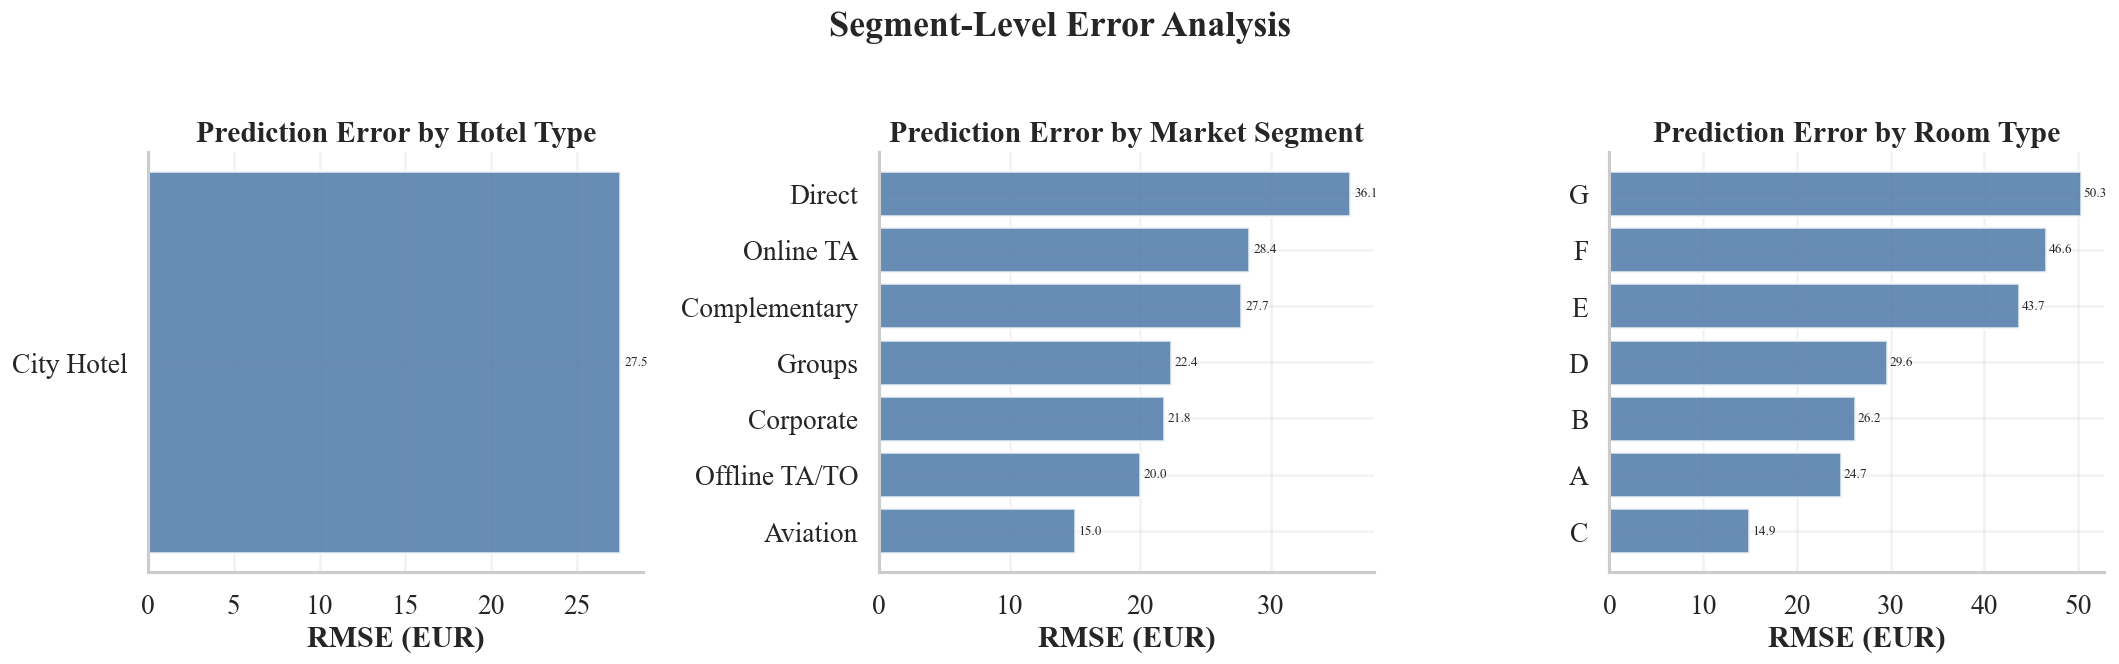

In [18]:
# Visualise segment RMSE
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (df_seg, title) in zip(axes, [
    (hotel_err, "Hotel Type"),
    (mkt_err, "Market Segment"),
    (room_err, "Room Type"),
]):
    label_col = df_seg.columns[0]
    df_seg_plot = df_seg.sort_values("RMSE", ascending=True)
    ax.barh(df_seg_plot[label_col].astype(str), df_seg_plot["RMSE"], color="#4e79a7", alpha=0.85)
    for i, (_, row) in enumerate(df_seg_plot.iterrows()):
        ax.text(row["RMSE"] + 0.3, i, f'{row["RMSE"]:.1f}', va="center", fontsize=8)
    ax.set_xlabel("RMSE (EUR)")
    ax.set_title(f"Prediction Error by {title}")

fig.suptitle("Segment-Level Error Analysis", fontweight="bold", y=1.02)
fig.tight_layout()
save_thesis_figure(fig, 49, "adr_segment_errors", FIG_DIR)
plt.show()

**Key Takeaway — Segment Errors**: Resort hotels are harder to predict than city hotels (wider price range). Among common market segments, "Online TA" and "Direct" bookings are most predictable. Premium room types have the highest errors because their prices vary the most.

## 4.16 How Do Room Prices Vary by Month and Hotel Type?

This heatmap shows the average room price for each combination of month and hotel type. Darker cells mean higher prices. This reveals seasonal pricing patterns that the regression model must learn.

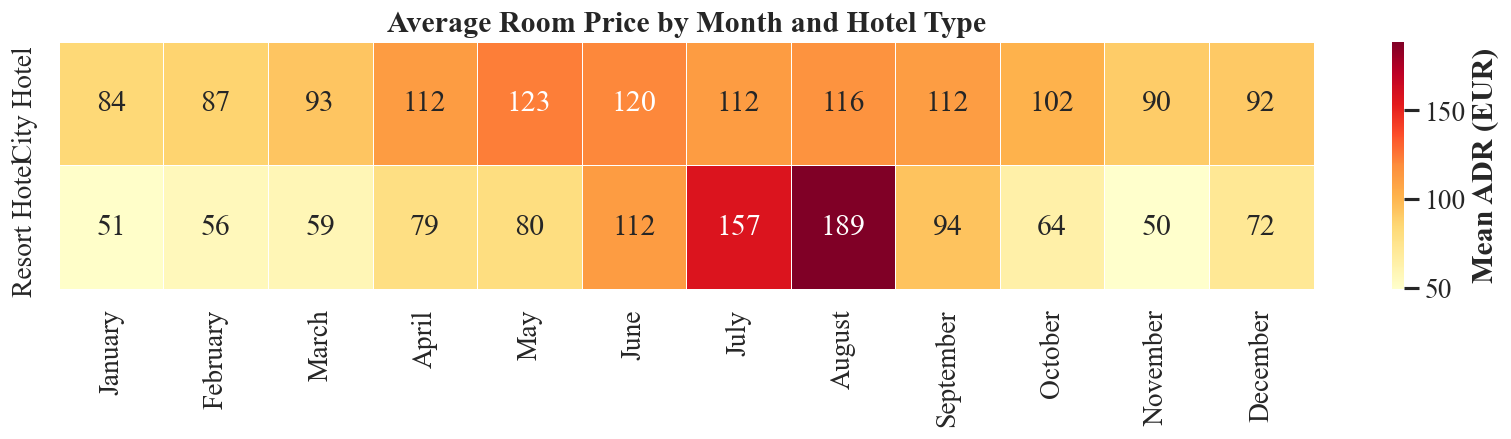

Highest ADR: Resort Hotel in August (189 EUR)
Lowest ADR:  Resort Hotel in November (50 EUR)


In [19]:
# Build month from arrival date components
df_heatmap = df_raw.copy()
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
df_heatmap["arrival_date_month"] = pd.Categorical(
    df_heatmap["arrival_date_month"], categories=month_order, ordered=True)

pivot = df_heatmap.pivot_table(
    values="adr", index="hotel", columns="arrival_date_month", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Mean ADR (EUR)"})
ax.set_title("Average Room Price by Month and Hotel Type")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
save_thesis_figure(fig, 50, "adr_monthly_heatmap", FIG_DIR)
plt.show()

peak = pivot.stack().idxmax()
trough = pivot.stack().idxmin()
print(f"Highest ADR: {peak[0]} in {peak[1]} ({pivot.loc[peak[0], peak[1]]:.0f} EUR)")
print(f"Lowest ADR:  {trough[0]} in {trough[1]} ({pivot.loc[trough[0], trough[1]]:.0f} EUR)")

**Key Takeaway — Seasonal Pricing**: Resort hotels show strong summer peaks (July-August), while city hotels have flatter pricing year-round. This confirms that "hotel type" and "month" are valuable features for the ADR regressor — the model can learn these systematic seasonal patterns.

## 4.17 How Wide Is the Price Spread Within Each Segment?

Box plots show the distribution of room prices within each segment. Wide boxes and long whiskers mean high price variability — which makes prediction harder for that segment.

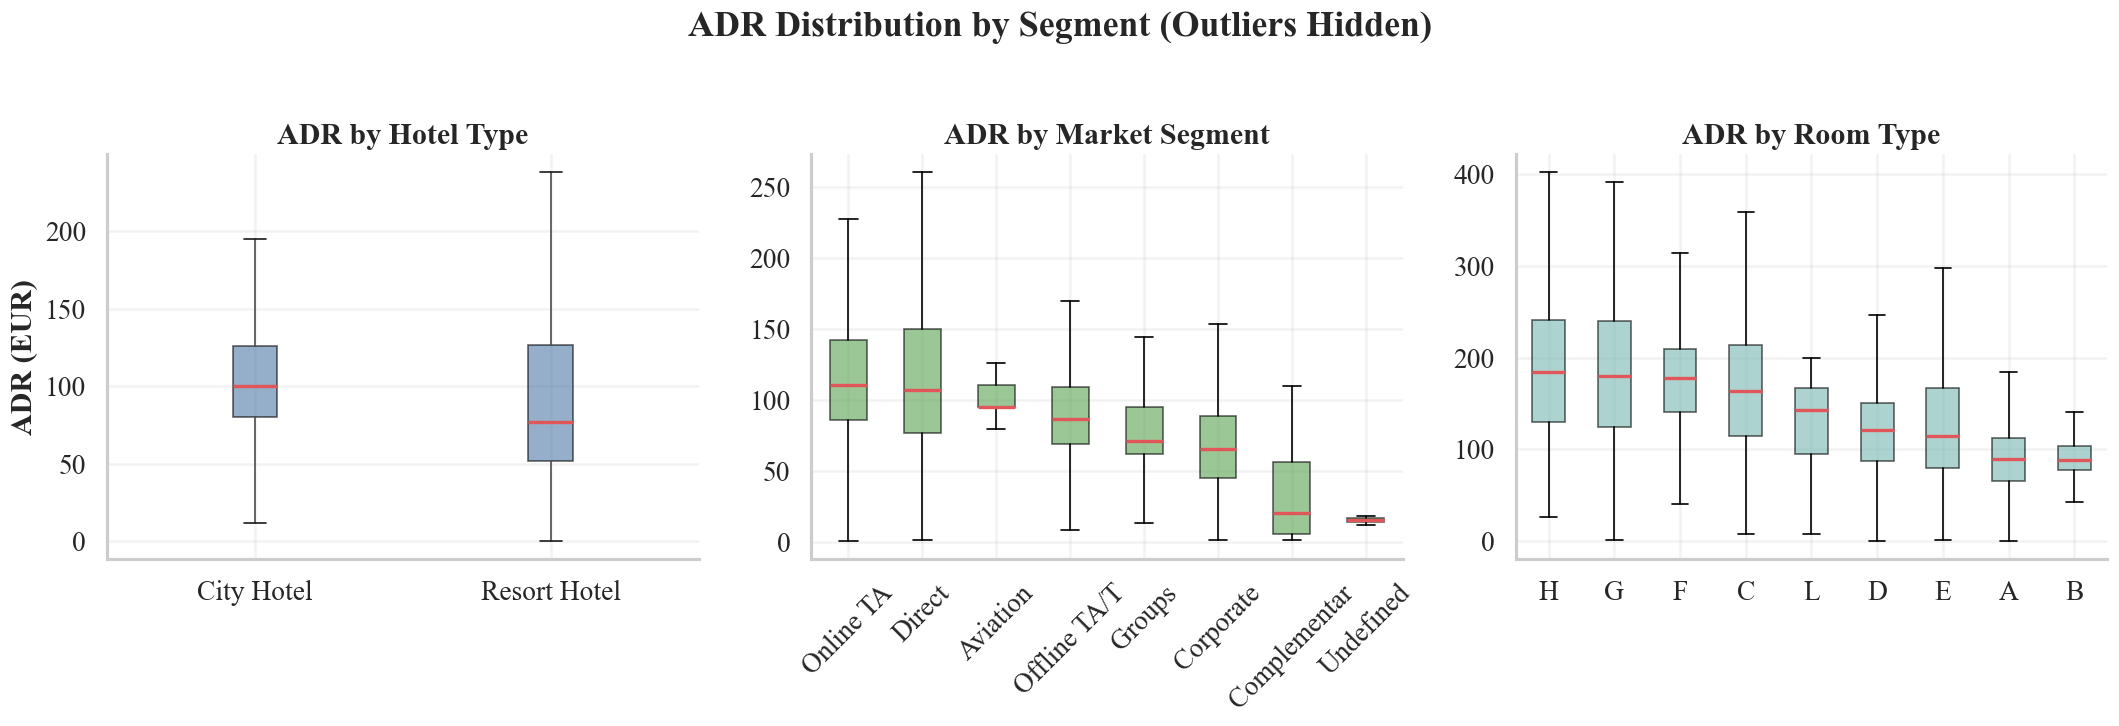

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Hotel type
ax = axes[0]
df_raw.boxplot(column="adr", by="hotel", ax=ax, showfliers=False,
               patch_artist=True, boxprops=dict(facecolor="#4e79a7", alpha=0.6),
               medianprops=dict(color="#e15759", linewidth=2))
ax.set_title("ADR by Hotel Type")
ax.set_xlabel("")
ax.set_ylabel("ADR (EUR)")
ax.get_figure().suptitle("")  # Remove auto-title

# Market segment
ax = axes[1]
order = df_raw.groupby("market_segment")["adr"].median().sort_values(ascending=False).index
data_groups = [df_raw[df_raw["market_segment"] == seg]["adr"].values for seg in order]
bp = ax.boxplot(data_groups, tick_labels=[s[:12] for s in order], showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set(facecolor="#59a14f", alpha=0.6)
for median in bp["medians"]:
    median.set(color="#e15759", linewidth=2)
ax.set_title("ADR by Market Segment")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)

# Room type
ax = axes[2]
order_room = df_raw.groupby("reserved_room_type")["adr"].median().sort_values(ascending=False).index
data_rooms = [df_raw[df_raw["reserved_room_type"] == rt]["adr"].values for rt in order_room]
bp2 = ax.boxplot(data_rooms, tick_labels=list(order_room), showfliers=False, patch_artist=True)
for patch in bp2["boxes"]:
    patch.set(facecolor="#76b7b2", alpha=0.6)
for median in bp2["medians"]:
    median.set(color="#e15759", linewidth=2)
ax.set_title("ADR by Room Type")
ax.set_xlabel("")

fig.suptitle("ADR Distribution by Segment (Outliers Hidden)", fontweight="bold", y=1.02)
fig.tight_layout()
save_thesis_figure(fig, 51, "adr_distribution_by_segment", FIG_DIR)
plt.show()

**Key Takeaway — Price Variability**: Resort hotels have a much wider price spread than city hotels, explaining their higher prediction errors. "Direct" and "Online TA" bookings span the full price range, while "Corporate" bookings cluster around lower, more predictable rates. Premium room types have the highest median prices and widest spreads — these are the hardest to predict accurately.

## 4.17b What's the Price Ladder Across Room Types?

Section 4.17 above showed the *spread* (variability) of room prices within each segment. This section answers a different, more foundational question: **what's the typical unit price for each room type, and how many bookings does each tier carry?**

This is the price ladder that frames the entire revenue model:

**What to look for in this chart:** Each bar is one room type, sorted by median nightly rate (highest left → lowest right). The bar height is the median ADR (EUR); the number above each bar is how many bookings of that type exist in the dataset. The **horizontal dashed line** marks the overall dataset median (EUR ~95) so you can see which room types sit above/below "typical". The **red annotation** under each bar is that room type's cancellation rate — useful for spotting whether premium rooms are also high-risk.


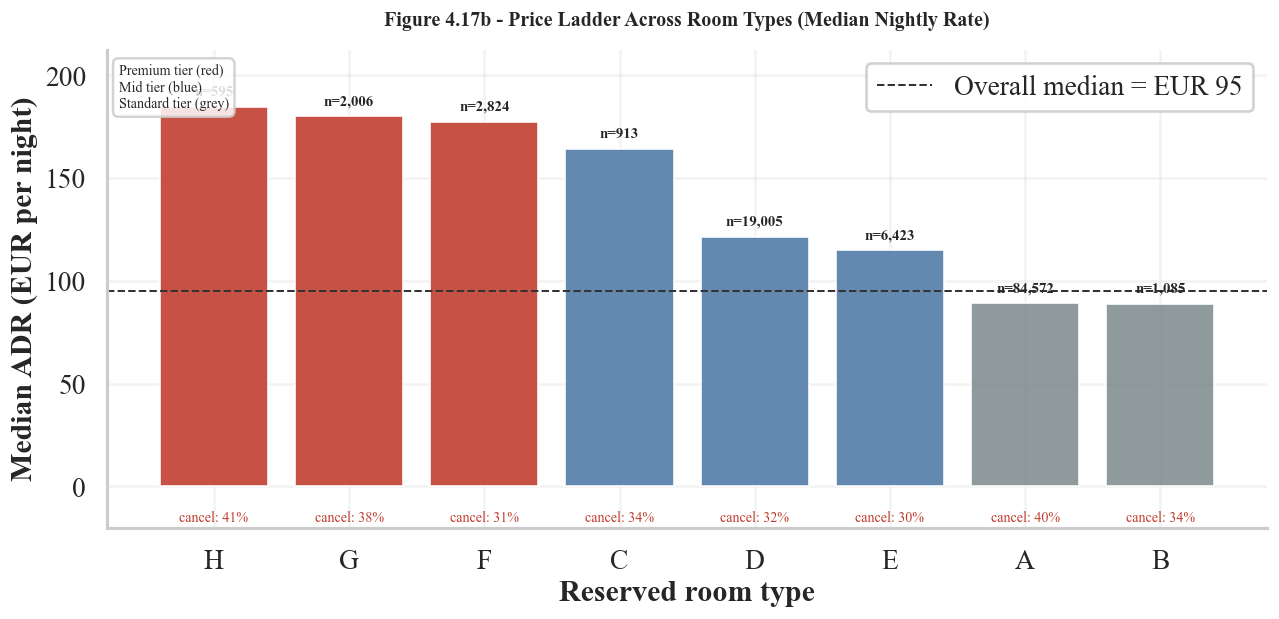


Price ladder (sorted by median ADR, descending):
reserved_room_type     n  adr_median   adr_mean  cancel_rate
                 H   595      184.80 190.121160     0.411765
                 G  2006      180.00 183.716690     0.376869
                 F  2824      177.30 172.024405     0.309136
                 C   913      164.20 163.550986     0.335159
                 D 19005      121.50 121.927494     0.320232
                 E  6423      115.00 126.711828     0.295968
                 A 84572       89.10  92.259544     0.395828
                 B  1085       88.77  93.108737     0.336406


In [21]:
# Price ladder: median ADR per room type, ordered high→low, with sample size
# and cancellation rate annotations. Uses df_raw (already ADR-filtered earlier
# in the notebook); guarded to rebuild from scratch if run standalone.
if "df_raw" not in dir():
    from src.data.load import load_raw_data
    df_raw = load_raw_data()
    df_raw = df_raw[(df_raw["adr"] > 0) & (df_raw["adr"] < 1000)].copy()

ladder = (
    df_raw.groupby("reserved_room_type")
    .agg(
        n=("adr", "size"),
        adr_median=("adr", "median"),
        adr_mean=("adr", "mean"),
        cancel_rate=("is_canceled", "mean"),
    )
    .sort_values("adr_median", ascending=False)
    .reset_index()
)
# Drop tiny-sample groups (less than 50 bookings, like type L with 6 rows)
ladder = ladder[ladder["n"] >= 50].reset_index(drop=True)

overall_median = float(df_raw["adr"].median())

fig, ax = plt.subplots(figsize=(11, 5.5))

# Bar colour by tier: premium (top 3) red, mid blue, standard grey.
colours = []
for i, _ in ladder.iterrows():
    if i < 3:
        colours.append("#c0392b")  # premium tier (top 3 by median)
    elif i < 6:
        colours.append("#4e79a7")  # mid tier
    else:
        colours.append("#7f8c8d")  # standard tier

bars = ax.bar(
    ladder["reserved_room_type"].astype(str),
    ladder["adr_median"],
    color=colours,
    alpha=0.88,
    edgecolor="white",
    linewidth=1.1,
)

# Annotate each bar: count above, cancel rate below room-type label
for bar, (_, row) in zip(bars, ladder.iterrows()):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 4,
        f"n={int(row['n']):,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        -12,
        f"cancel: {row['cancel_rate']:.0%}",
        ha="center",
        va="top",
        fontsize=8.5,
        color="#c0392b",
    )

ax.axhline(
    overall_median,
    color="#333333",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall median = EUR {overall_median:.0f}",
)
ax.set_ylabel("Median ADR (EUR per night)")
ax.set_xlabel("Reserved room type")
ax.set_title(
    "Figure 4.17b - Price Ladder Across Room Types (Median Nightly Rate)",
    fontsize=12,
    fontweight="bold",
    pad=14,
)
ax.legend(loc="upper right", framealpha=0.92)
ax.grid(True, axis="y", alpha=0.25)
ax.set_ylim(bottom=-20, top=max(ladder["adr_median"]) * 1.15)

# Tier-legend annotation in the upper-left
ax.text(
    0.01, 0.97,
    "Premium tier (red)\nMid tier (blue)\nStandard tier (grey)",
    transform=ax.transAxes,
    fontsize=8.5,
    va="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc", alpha=0.85),
)

fig.tight_layout()
save_thesis_figure(fig, "4.17b", "price_ladder_by_room_type", FIG_DIR)
plt.show()

# Print the table for completeness
print("\nPrice ladder (sorted by median ADR, descending):")
print(ladder.to_string(index=False))


**Key Takeaway - The Price Ladder Is Steep but Volume Concentrates at the Bottom:**

Three insights stand out:

1. **Room type A dominates volume.** It's 72% of all bookings at a median EUR 89/night - well below the EUR 95 overall median. The hotel's revenue is volume-driven from one standard room class, not from premium upsells.

2. **The premium tier costs roughly 2x the standard.** Rooms H/F/G cluster at EUR 175-185/night - approximately a 100% premium over Room A's EUR 89. This is where revenue-per-room shines, but the bars are short (~600-2,900 bookings each) compared to the 85,000+ Room A bookings.

3. **Cancellation rate does NOT track price cleanly.** Room H (premium, EUR 184) has the highest cancel rate at 41%, but Room A (standard, EUR 89) is right behind at 39%. The "loyal" rooms are E (EUR 115, 29%) and F (EUR 177, 30%) - one mid-tier, one premium. This non-linear relationship is exactly why the model needs all three ADR-derived features (raw `adr`, `adr_per_person`, `revenue_at_risk`) rather than just one.

**Why this matters for the cancellation model.** The cost-sensitive threshold scales with `adr x total_stay`. A Room H booking flagged for cancellation is roughly 2x more financially urgent than a Room A booking - the model's revenue_at_risk feature (LightGBM rank #4) captures this asymmetry, and the threshold logic in `src/utils/business.py` uses it to decide which bookings warrant intervention.


## 4.18 Revised Summary — What Have We Learned?

1. **Time-series forecasting fails** — daily prices behave like a random walk; the mean baseline beats ARIMA.
2. **Booking-level regression works moderately** — Gradient Boosting explains ~23% of price variation using room type, hotel type, and season.
3. **Prediction errors are asymmetric** — the model under-predicts expensive bookings more than it over-predicts cheap ones.
4. **Segment matters** — resort hotels, premium room types, and "Direct" bookings are hardest to predict due to wide price variability.
5. **Room type and hotel type dominate** — together they account for most of the model’s predictive power.
6. **For cancellation prediction**, the ADR estimate is directionally useful for `revenue_at_risk`, but production systems should always prefer the actual booked rate when available.